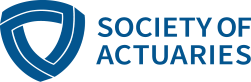

# 🔀 01 Data Ingestion & Preparation

|                  |                                                                                             |
| ---------------- | ------------------------------------------------------------------------------------------- |
| Title            | 01 Data Ingestion & Preparation                                                             |
| Case Study       | Climate-Adjusted Mortality for Selected EU Countries                                        |
| Research Project | CC230 Quantifying Mortality and Morbidity Impacts from Climate Risks                       |
| Notebook         | `01_data_ingestion_and_preparation.ipynb`                                                   |
| Author           | Carlos Arocha, FSA, SCR                                                                     |
| Sponsor          | Catastrophe and Climate Strategic Research Program, Society of Actuaries Research Institute |
| Date             | `2026-05-11`                                                                                |
| Version          | `v1.0.0`                                                                                    |
| Questions?       | Questions regarding this notebook should be directed to the SOA project contact             |

---

## Purpose
Load raw data, including, mortality datasets, climate datasets, and metadata, and prepare data for analysis

---

## Inputs

Raw mortality files:

- `CC230 Toolkit/data/raw/demographic/mortality_mx_{COUNTRY}.csv`

Raw climate files:

- `CC230 Toolkit/data/raw/climate/era5_monthly_t2m.nc`
- `CC230 Toolkit/data/raw/climate/era5_daily_tmax_*.nc` (one file for each of the calibration years)
- `CC230 Toolkit/data/raw/climate/cmip6_monthly_tas_{SCENARIO}_2030_2060.nc`
- `CC230 Toolkit/data/raw/climate/cmip6_daily_tasmax_{SCENARIO}_2030_2060.nc`

---

## Outputs

Configuration files:

- `CC230 Toolkit/data/interim/run_config.json`
- `CC230 Toolkit/data/interim/input_manifest.csv`
- `CC230 Toolkit/data/interim/output_manifest.csv`

Processed data files:

- `CC230 Toolkit/data/processed/demographic/mortality_country_age_year.csv`
- `CC230 Toolkit/data/processed/climate/heat_metrics_country_annual_era5.csv`
- `CC230 Toolkit/data/processed/climate/heat_thresholds_country_era5.csv`
- `CC230 oolkit/data/processed/climate/temperature_anomaly_country_annual_era5.csv`
- `CC230 Toolkit/data/processed/climate/heat_metrics_country_annual_cmip6_{SCENARIO}_2030_2060.csv`
- `CC230 Toolkit/data/processed/climate/heat_metrics_country_annual_combined_era5_cmip6_{SCENARIO}.csv`
- `CC230 Toolkit/data/processed/climate/temperature_anomaly_country_annual_cmip6_{SCENARIO}_2030_2060.csv`
- `CC230 Toolkit/data/processed/climate/temperature_anomaly_country_annual_combined_era5_cmip6_{SCENARIO}.csv`

Report:
- `CC230 Toolkit/reports/{NOTEBOOK}.html`

---

## Dependencies

This notebook can be run in Google Colab or any compatible Jupyter environment, such as:

* JupyterLab
* Jupyter Notebook
* VS Code with the Jupyter extension
* Anaconda Navigator
* Kaggle Notebooks

The notebook was developed using:

* Python 3.14.5
* Required libraries installed through the setup cell below

---

## Disclaimer
The Jupyter notebooks available through this repository are provided for research, educational, and illustrative purposes only. They are not intended to constitute actuarial advice or to represent production-ready systems without further validation, customization, and governance by the user.

While reasonable efforts have been made to ensure accuracy and consistency, no guarantee is given as to completeness, fitness for a particular purpose, or compliance with applicable actuarial standards or regulatory requirements.

Users are responsible for assessing the suitability of the materials for their specific use cases and for implementing appropriate controls, validation, and documentation prior to any operational use.

---

## License
© 2026 Society of Actuaries. Except where otherwise noted, the textual content of this book is licensed under the Creative Commons Attribution–Noncommercial–Share Alike 4.0 International License (CC BY-NC-SA 4.0). Source code samples, including scripts, notebooks, and code blocks where indicated, are licensed under the MIT License, unless otherwise stated.

---

## Setup

In [1]:
# Install required libraries
from pathlib import Path, PureWindowsPath
import json
from datetime import datetime, UTC

import numpy as np
import pandas as pd
import xarray as xr
import subprocess
import sys

%pip install -q netCDF4 h5netcdf dask

pd.set_option("display.max_columns", None)

PROJECT_ROOT = Path.cwd().parent.resolve()

if PROJECT_ROOT.parts[-1] != "CC230 Toolkit":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent.resolve()

# Core folders
DATA_PATH = PROJECT_ROOT / "data"
RAW_DATA_PATH = DATA_PATH / "raw"
PROCESSED_DATA_PATH = DATA_PATH / "processed"
INTERIM_DATA_PATH = DATA_PATH / "interim"
OUTPUT_PATH = PROJECT_ROOT / "outputs"
REPORTS_PATH = PROJECT_ROOT / "reports"

for folder in [
    DATA_PATH,
    RAW_DATA_PATH,
    PROCESSED_DATA_PATH,
    INTERIM_DATA_PATH,
    OUTPUT_PATH,
    REPORTS_PATH,
    PROCESSED_DATA_PATH / "mortality",
    PROCESSED_DATA_PATH / "climate",
]:
    folder.mkdir(parents=True, exist_ok=True)

NOTEBOOK_FILE = PROJECT_ROOT / "notebooks" / "01_data_ingestion_and_preparation.ipynb"    

Note: you may need to restart the kernel to use updated packages.


## Case Study Parameters

This is the only section in the notebook suite where case-study parameters should be entered. Subsequent notebooks should read these values from # data/interim/run_config.json.

### Climate Scenario Data Sources

Climate scenario data used in IPCC assessments can be accessed from official and widely used scientific data portals. Users may download scenario data from the following sources:

* **IPCC Data Distribution Centre (DDC)**: Provides climate, socio-economic, and environmental data used in IPCC reports, including historical observations and future scenario data.
  https://www.ipcc-data.org/

* **IPCC AR6 Scenario Explorer and Database**: Provides model-based emissions, energy, land-use, and socio-economic pathways used in the IPCC Sixth Assessment Report.
  https://data.ene.iiasa.ac.at/ar6/

* **CMIP6 / ESGF Climate Model Data**: Provides global climate model projections used in many IPCC assessments, including SSP-based climate scenarios such as SSP1-2.6, SSP2-4.5, SSP3-7.0, and SSP5-8.5.
  https://esgf-node.llnl.gov/projects/cmip6/

* **Copernicus Climate Data Store — CMIP6 projections**: Provides access to selected CMIP6 climate projection datasets in a user-friendly data catalogue.
  https://cds.climate.copernicus.eu/

Users should review the data license, citation requirements, model documentation, scenario definitions, and spatial/temporal resolution before using these datasets for analysis.


In [2]:
# Case study parameters

SCENARIO = "ssp5_8_5"  # climate files available for "ssp2_4_5" and "ssp5_8_5"

COUNTRIES = ["ES", "FR", "IT"]

COUNTRY_BOXES = {
    "ES": {"lat_min": 36.0, "lat_max": 43.7, "lon_min": - 9.5, "lon_max":  2.7},
    "FR": {"lat_min": 42.5, "lat_max": 51.0, "lon_min":  -5.0, "lon_max":  8.0},
    "IT": {"lat_min": 37.0, "lat_max": 47.0, "lon_min":   6.5, "lon_max": 18.0},    
}

CALIBRATION_START_YEAR = 2004
CALIBRATION_END_YEAR   = 2025
EXCLUDED_CALIBRATION_YEARS = [2020, 2021]

CALIBRATION_YEARS = [
    year
    for year in range(CALIBRATION_START_YEAR, CALIBRATION_END_YEAR + 1)
    if year not in EXCLUDED_CALIBRATION_YEARS
]

N_CALIBRATION_YEARS = len(CALIBRATION_YEARS)

PROJECTION_START_YEAR = 2030
PROJECTION_END_YEAR   = 2060

AGE_MIN = 20
AGE_MAX = 85
AGE_RANGE = list(range(AGE_MIN, AGE_MAX + 1))

FIXED_HEAT_THRESHOLD_C = 30.0
HEAT_PERCENTILE_THRESHOLD = 0.95
MIN_HEATWAVE_LENGTH_DAYS = 6

W_TEMP_ANOMALY      = 0.20
W_EXTREME_HEAT_DAYS = 0.70
W_HEATWAVE_DURATION = 0.10

STRICT_INPUT_CHECK = True

EXCLUDED_YEARS_LABEL = (
    "none"
    if len(EXCLUDED_CALIBRATION_YEARS) == 0
    else "_".join(str(y) for y in EXCLUDED_CALIBRATION_YEARS)
)

CALIBRATION_YEARS_LABEL = (
    f"{CALIBRATION_START_YEAR}_{CALIBRATION_END_YEAR}"
    if EXCLUDED_YEARS_LABEL == "none"
    else f"{CALIBRATION_START_YEAR}_{CALIBRATION_END_YEAR}_excl_{EXCLUDED_YEARS_LABEL}"
)

AGE_RANGE_LABEL = f"age{AGE_MIN}_{AGE_MAX}"

HEAT_PERCENTILE_LABEL = int(round(100 * HEAT_PERCENTILE_THRESHOLD))
FIXED_HEAT_THRESHOLD_LABEL = f"{int(FIXED_HEAT_THRESHOLD_C)}c"

HEAT_EXTREME_DAYS_FIXED_COL = f"extreme_heat_days_{FIXED_HEAT_THRESHOLD_LABEL}"
HEAT_EXTREME_DAYS_PERCENTILE_COL = f"extreme_heat_days_p{HEAT_PERCENTILE_LABEL}"
HEATWAVE_DAYS_COL = f"heatwave_days_p{HEAT_PERCENTILE_LABEL}_{MIN_HEATWAVE_LENGTH_DAYS}d"
HEAT_THRESHOLD_COL = f"threshold_p{HEAT_PERCENTILE_LABEL}_c"

print(f"Scenario: {SCENARIO}")
print(f"Countries: {COUNTRIES}")
print(f"Calibration years: {CALIBRATION_YEARS}")
print(f"Number of calibration years: {N_CALIBRATION_YEARS}")
print(f"Age range: {AGE_MIN}-{AGE_MAX}")

Scenario: ssp5_8_5
Countries: ['ES', 'FR', 'IT']
Calibration years: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2022, 2023, 2024, 2025]
Number of calibration years: 20
Age range: 20-85


In [3]:
# File definitions

mortality_files = {
    country: RAW_DATA_PATH / "demographic" / f"mortality_mx_{country}.csv"
    for country in COUNTRIES
}

era5_monthly_t2m_file = (
    RAW_DATA_PATH
    / "climate"
    / "era5_monthly_t2m.nc"
)

cmip6_monthly_tas_file = (
    RAW_DATA_PATH
    / "climate"
    / f"cmip6_monthly_tas_{SCENARIO}_{PROJECTION_START_YEAR}_{PROJECTION_END_YEAR}.nc"
)

def extract_final_year_from_path(path):
    """Extract the final underscore-delimited year from a file stem."""
    try:
        return int(Path(path).stem.split("_")[-1])
    except ValueError:
        return None

era5_daily_tmax_files = sorted(
    file_path
    for file_path in RAW_DATA_PATH.glob("climate/era5_daily_tmax_*.nc")
    if extract_final_year_from_path(file_path) in CALIBRATION_YEARS
)

cmip6_daily_tasmax_file = (
    RAW_DATA_PATH
    / "climate"
    / f"cmip6_daily_tasmax_{SCENARIO}_{PROJECTION_START_YEAR}_{PROJECTION_END_YEAR}.nc"
)

mortality_output_file = (
    PROCESSED_DATA_PATH
    / "mortality"
    / f"country_age_year_{CALIBRATION_YEARS_LABEL}_{AGE_RANGE_LABEL}.csv"
)

temperature_anomaly_era5_file = (
    PROCESSED_DATA_PATH
    / "climate"
    / f"temperature_anomaly_country_annual_era5_{CALIBRATION_YEARS_LABEL}.csv"
)

temperature_anomaly_cmip6_file = (
    PROCESSED_DATA_PATH
    / "climate"
    / f"temperature_anomaly_country_annual_cmip6_{SCENARIO}_{PROJECTION_START_YEAR}_{PROJECTION_END_YEAR}.csv"
)

temperature_anomaly_combined_file = (
    PROCESSED_DATA_PATH
    / "climate"
    / f"temperature_anomaly_country_annual_combined_era5_cmip6_{SCENARIO}.csv"
)

heat_metrics_era5_file = (
    PROCESSED_DATA_PATH
    / "climate"
    / f"heat_metrics_country_annual_era5_{CALIBRATION_YEARS_LABEL}.csv"
)

heat_thresholds_era5_file = (
    PROCESSED_DATA_PATH
    / "climate"
    / f"heat_thresholds_country_era5_{CALIBRATION_YEARS_LABEL}.csv"
)

heat_metrics_cmip6_file = (
    PROCESSED_DATA_PATH
    / "climate"
    / f"heat_metrics_country_annual_cmip6_{SCENARIO}_{PROJECTION_START_YEAR}_{PROJECTION_END_YEAR}.csv"
)

heat_metrics_combined_file = (
    PROCESSED_DATA_PATH
    / "climate"
    / f"heat_metrics_country_annual_combined_era5_cmip6_{SCENARIO}.csv"
)

run_config_file = INTERIM_DATA_PATH / "run_config.json"
input_manifest_file = INTERIM_DATA_PATH / "input_manifest.csv"
output_manifest_file = INTERIM_DATA_PATH / "01_data_ingestion_and_preparation_output_manifest.csv"

print("Key output files:")
print(PureWindowsPath(mortality_output_file).name)
print(PureWindowsPath(temperature_anomaly_combined_file).name)
print(PureWindowsPath(heat_metrics_combined_file).name)

Key output files:
country_age_year_2004_2025_excl_2020_2021_age20_85.csv
temperature_anomaly_country_annual_combined_era5_cmip6_ssp5_8_5.csv
heat_metrics_country_annual_combined_era5_cmip6_ssp5_8_5.csv


In [4]:
# Helper functions

def path_to_project_relative(path):
    """Return a project-relative path when possible."""
    path = Path(path)
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)

def register_file(role, path, file_type=None, required=True, stage="input", notes=None):
    """Create a file registry record used in cross-notebook manifests."""
    path = Path(path)
    return {
        "stage": stage,
        "role": role,
        "file_name": path.name,
        "relative_path": path_to_project_relative(path),
        "absolute_path": str(path),
        "file_type": file_type if file_type is not None else path.suffix.replace(".", ""),
        "required": bool(required),
        "exists": path.exists(),
        "notes": notes,
    }

def build_input_manifest():
    records = []

    for country, file_path in mortality_files.items():
        records.append(
            register_file(
                role=f"raw_mortality_mx_{country}",
                path=file_path,
                file_type="csv",
                required=True,
                stage="input",
                notes=f"Mortality rates for {country}, including projected 2023-2025 values where applicable",
            )
        )

    records.append(
        register_file(
            role="raw_historical_monthly_t2m",
            path=era5_monthly_t2m_file,
            file_type="netcdf",
            required=True,
            stage="input",
            notes="ERA5 monthly 2m temperature for historical temperature anomaly calculation",
        )
    )

    records.append(
        register_file(
            role="raw_projection_monthly_tas",
            path=cmip6_monthly_tas_file,
            file_type="netcdf",
            required=True,
            stage="input",
            notes=f"CMIP6 monthly near-surface air temperature for {SCENARIO}",
        )
    )

    for file_path in era5_daily_tmax_files:
        year = extract_final_year_from_path(file_path)
        records.append(
            register_file(
                role=f"raw_historical_daily_tmax_{year}",
                path=file_path,
                file_type="netcdf",
                required=True,
                stage="input",
                notes=f"ERA5 daily maximum 2m temperature for calibration year {year}",
            )
        )

    records.append(
        register_file(
            role="raw_projection_daily_tasmax",
            path=cmip6_daily_tasmax_file,
            file_type="netcdf",
            required=True,
            stage="input",
            notes=f"CMIP6 daily maximum near-surface air temperature for {SCENARIO}",
        )
    )

    return pd.DataFrame(records)

def build_output_manifest():
    output_records = [
        ("processed_mortality_mx", mortality_output_file, "csv", "Country-age-year mortality rates"),
        ("processed_temperature_anomaly_era5", temperature_anomaly_era5_file, "csv", "Historical country-year temperature anomalies"),
        ("processed_temperature_anomaly_cmip6", temperature_anomaly_cmip6_file, "csv", "Projected country-year temperature anomalies"),
        ("processed_temperature_anomaly_combined", temperature_anomaly_combined_file, "csv", "Combined historical and projected temperature anomalies"),
        ("processed_heat_metrics_era5", heat_metrics_era5_file, "csv", "Historical country-year heat metrics"),
        ("processed_heat_thresholds_era5", heat_thresholds_era5_file, "csv", "Country-specific historical heat thresholds"),
        ("processed_heat_metrics_cmip6", heat_metrics_cmip6_file, "csv", "Projected country-year heat metrics"),
        ("processed_heat_metrics_combined", heat_metrics_combined_file, "csv", "Combined historical and projected heat metrics"),
    ]

    records = [
        register_file(
            role=role,
            path=path,
            file_type=file_type,
            required=True,
            stage="output",
            notes=notes,
        )
        for role, path, file_type, notes in output_records
    ]

    return pd.DataFrame(records)

def write_run_config():
    """Write run configuration used by downstream notebooks."""
    run_config = {
        "notebook": "01_data_ingestion_and_preparation.ipynb",
        "created_at_utc": datetime.now(UTC).isoformat(),
        "project_root": str(PROJECT_ROOT),
        "data_path": str(DATA_PATH),
        "raw_data_path": str(RAW_DATA_PATH),
        "processed_data_path": str(PROCESSED_DATA_PATH),
        "interim_data_path": str(INTERIM_DATA_PATH),
        "output_path": str(OUTPUT_PATH),

        "scenario": SCENARIO,
        "countries": COUNTRIES,
        "country_boxes": COUNTRY_BOXES,

        "calibration_start_year": CALIBRATION_START_YEAR,
        "calibration_end_year": CALIBRATION_END_YEAR,
        "excluded_calibration_years": EXCLUDED_CALIBRATION_YEARS,
        "calibration_years": CALIBRATION_YEARS,
        "n_calibration_years": N_CALIBRATION_YEARS,
        "calibration_years_label": CALIBRATION_YEARS_LABEL,

        "projection_start_year": PROJECTION_START_YEAR,
        "projection_end_year": PROJECTION_END_YEAR,

        "age_min": AGE_MIN,
        "age_max": AGE_MAX,
        "age_range_label": AGE_RANGE_LABEL,

        "fixed_heat_threshold_c": FIXED_HEAT_THRESHOLD_C,
        "heat_percentile_threshold": HEAT_PERCENTILE_THRESHOLD,
        "heat_percentile_label": HEAT_PERCENTILE_LABEL,
        "min_heatwave_length_days": MIN_HEATWAVE_LENGTH_DAYS,

        "heat_extreme_days_fixed_col": HEAT_EXTREME_DAYS_FIXED_COL,
        "heat_extreme_days_percentile_col": HEAT_EXTREME_DAYS_PERCENTILE_COL,
        "heatwave_days_col": HEATWAVE_DAYS_COL,
        "heat_threshold_col": HEAT_THRESHOLD_COL,

        "w_temp_anomaly": W_TEMP_ANOMALY,
        "w_extreme_heat_days": W_EXTREME_HEAT_DAYS,
        "w_heatwave_duration": W_HEATWAVE_DURATION,

        "files": {
            "mortality_output_file": str(mortality_output_file),
            "temperature_anomaly_era5_file": str(temperature_anomaly_era5_file),
            "temperature_anomaly_cmip6_file": str(temperature_anomaly_cmip6_file),
            "temperature_anomaly_combined_file": str(temperature_anomaly_combined_file),
            "heat_metrics_era5_file": str(heat_metrics_era5_file),
            "heat_thresholds_era5_file": str(heat_thresholds_era5_file),
            "heat_metrics_cmip6_file": str(heat_metrics_cmip6_file),
            "heat_metrics_combined_file": str(heat_metrics_combined_file),
        },
    }

    with open(run_config_file, "w", encoding="utf-8") as f:
        json.dump(run_config, f, indent=4)

    return run_config

# Create input manifest file and configuration file
run_config = write_run_config()
input_manifest = build_input_manifest()
input_manifest.to_csv(input_manifest_file, index=False)

print("Saved cross-notebook configuration:")
print(PureWindowsPath(run_config_file).name)
print(PureWindowsPath(input_manifest_file).name)

Saved cross-notebook configuration:
run_config.json
input_manifest.csv


In [5]:
# Input completeness checks

required_inputs_missing = input_manifest[
    input_manifest["required"].eq(True)
    & input_manifest["exists"].eq(False)
].copy()

expected_daily_years = set(CALIBRATION_YEARS)
available_daily_years = {
    extract_final_year_from_path(file_path)
    for file_path in era5_daily_tmax_files
}
missing_daily_years = sorted(expected_daily_years - available_daily_years)

if not required_inputs_missing.empty:
    print("Missing required input files:")
    display(required_inputs_missing[["role", "file_name", "absolute_path", "notes"]])

if missing_daily_years:
    print(f"Missing ERA5 daily files for calibration years: {missing_daily_years}")

if STRICT_INPUT_CHECK and (not required_inputs_missing.empty or missing_daily_years):
    raise FileNotFoundError(
        "One or more required input files are missing. "
        "Review data/interim/input_manifest.csv, add the missing files, and rerun this notebook."
    )

if required_inputs_missing.empty and not missing_daily_years:
    print("All required input files were found.")



All required input files were found.


## Mortality Datasets

In [6]:
def standardize_mortality_columns(df, file_path):
    """Normalize mortality column names and infer country from file name if needed."""
    df = df.copy()

    normalized_names = {
        col: col.strip().lower().replace(" ", "_")
        for col in df.columns
    }
    df = df.rename(columns=normalized_names)

    rename_candidates = {
        "year": ["year", "yr"],
        "age": ["age", "x"],
        "mx": ["mx", "m_x", "central_death_rate", "central_mortality_rate"],
        "country": ["country", "iso2", "iso_code"],
    }

    rename_map = {}
    for standard_name, candidates in rename_candidates.items():
        for candidate in candidates:
            if candidate in df.columns:
                rename_map[candidate] = standard_name
                break

    df = df.rename(columns=rename_map)

    required_cols = {"year", "age", "mx"}
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(
            f"{Path(file_path).name} is missing required columns: {missing_cols}. "
            f"Available columns: {list(df.columns)}"
        )

    if "country" not in df.columns:
        country_match = [
            country
            for country in COUNTRIES
            if f"_{country}_" in Path(file_path).name or Path(file_path).stem.endswith(f"_{country}")
        ]

        if len(country_match) != 1:
            raise ValueError(
                f"Could not infer country from file name: {Path(file_path).name}"
            )

        df["country"] = country_match[0]

    df["country"] = df["country"].astype(str).str.upper()
    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df["age_num"] = pd.to_numeric(df["age"], errors="coerce")
    df["mx"] = pd.to_numeric(df["mx"], errors="coerce")

    return df

def read_and_filter_mortality_file(file_path):
    """Read one mortality file and keep only country, age, year, and mx."""
    df = pd.read_csv(file_path)
    df = standardize_mortality_columns(df, file_path)

    df = df[
        df["country"].isin(COUNTRIES)
        & df["year"].isin(CALIBRATION_YEARS)
        & df["age_num"].between(AGE_MIN, AGE_MAX)
        & df["mx"].notna()
        & (df["mx"] > 0)
    ].copy()

    df["year"] = df["year"].astype(int)
    df["age"] = df["age_num"].astype(int)

    df = df[["age", "country", "year", "mx"]].copy()
    df = df.sort_values(["country", "year", "age"]).reset_index(drop=True)

    return df

combined_mortality = pd.concat(
    [read_and_filter_mortality_file(file_path) for file_path in mortality_files.values()],
    ignore_index=True
)

combined_mortality = (
    combined_mortality
    .sort_values(["country", "year", "age"])
    .reset_index(drop=True)
)

combined_mortality.to_csv(mortality_output_file, index=False)

print(f"Saved mortality file to: {PureWindowsPath(mortality_output_file).name}")
print(f"Rows: {len(combined_mortality):,}")

mortality_completeness = (
    combined_mortality
    .groupby("country", as_index=False)
    .agg(
        min_year=("year", "min"),
        max_year=("year", "max"),
        n_years=("year", "nunique"),
        min_age=("age", "min"),
        max_age=("age", "max"),
        n_ages=("age", "nunique"),
        n_rows=("mx", "size"),
    )
)

expected_rows = len(COUNTRIES) * len(CALIBRATION_YEARS) * len(AGE_RANGE)
if len(combined_mortality) != expected_rows:
    print(f"Expected {expected_rows:,} rows but found {len(combined_mortality):,}.")
    missing_grid = (
        pd.MultiIndex.from_product(
            [COUNTRIES, CALIBRATION_YEARS, AGE_RANGE],
            names=["country", "year", "age"]
        )
        .to_frame(index=False)
        .merge(combined_mortality[["country", "year", "age"]], how="left", indicator=True)
        .query("_merge == 'left_only'")
        .drop(columns="_merge")
    )
else:
    print("Mortality data are complete for the selected countries, years, and ages.")

Saved mortality file to: country_age_year_2004_2025_excl_2020_2021_age20_85.csv
Rows: 3,960
Mortality data are complete for the selected countries, years, and ages.


## Climate Helper Functions

In [7]:
# Climate helper functions

def get_temperature_da(ds, preferred_vars):
    """Select a temperature variable from an xarray dataset."""
    for variable in preferred_vars:
        if variable in ds.data_vars:
            return ds[variable]

    raise ValueError(
        f"None of the preferred variables were found: {preferred_vars}. "
        f"Available variables: {list(ds.data_vars)}"
    )

def normalize_temperature_da(da):
    """Standardize coordinate names, longitude convention, and temperature units."""
    da = da.copy()

    rename = {}
    if "valid_time" in da.coords or "valid_time" in da.dims:
        rename["valid_time"] = "time"
    if "latitude" in da.coords or "latitude" in da.dims:
        rename["latitude"] = "lat"
    if "longitude" in da.coords or "longitude" in da.dims:
        rename["longitude"] = "lon"

    if rename:
        da = da.rename(rename)

    da = da.squeeze(drop=True)

    if "time" not in da.coords:
        raise ValueError("No time coordinate found.")
    if "lat" not in da.coords or "lon" not in da.coords:
        raise ValueError("Latitude/longitude coordinates not found.")

    if float(da["lon"].max()) > 180:
        da = da.assign_coords(lon=(((da["lon"] + 180) % 360) - 180))
        da = da.sortby("lon")

    units = str(da.attrs.get("units", "")).lower()
    sample_value = float(da.isel(time=0).mean(skipna=True).compute())

    if ("k" in units) or (sample_value > 100):
        da = da - 273.15
        da.attrs["units"] = "degC"

    return da

def subset_bbox(da, bbox):
    """Subset an xarray DataArray to a rectangular bounding box."""
    lat_values = da["lat"].values

    if lat_values[0] > lat_values[-1]:
        lat_slice = slice(bbox["lat_max"], bbox["lat_min"])
    else:
        lat_slice = slice(bbox["lat_min"], bbox["lat_max"])

    lon_slice = slice(bbox["lon_min"], bbox["lon_max"])

    return da.sel(lat=lat_slice, lon=lon_slice)

def area_weighted_mean(da):
    """Compute a cosine-latitude weighted spatial mean."""
    weights = np.cos(np.deg2rad(da["lat"]))
    return da.weighted(weights).mean(dim=["lat", "lon"], skipna=True)

def annual_mean_from_monthly(da):
    """Convert monthly observations to annual means using month-length weights."""
    month_length = da["time"].dt.days_in_month

    annual = (
        (da * month_length)
        .groupby("time.year")
        .sum(skipna=True)
        / month_length.groupby("time.year").sum()
    )

    return annual

def country_annual_temperature(da, country_boxes):
    """Compute annual mean temperature by country box."""
    rows = []

    for country, bbox in country_boxes.items():
        sub = subset_bbox(da, bbox)
        country_monthly = area_weighted_mean(sub).load()
        country_annual = annual_mean_from_monthly(country_monthly)

        rows.append(
            pd.DataFrame({
                "country": country,
                "year": country_annual["year"].values.astype(int),
                "temperature_c": country_annual.values,
            })
        )

    return pd.concat(rows, ignore_index=True)

def get_daily_tmax_from_ds(ds):
    """Extract daily maximum temperature and standardize coordinates and units."""
    candidate_vars = [
        "t2m",
        "mx2t",
        "tasmax",
        "daily_maximum_2m_temperature",
        "maximum_2m_temperature_since_previous_post_processing",
        "2m_temperature",
    ]

    var = next((v for v in candidate_vars if v in ds.data_vars), None)

    if var is None:
        raise ValueError(
            f"No recognized daily maximum temperature variable found. "
            f"Available variables: {list(ds.data_vars)}"
        )

    return normalize_temperature_da(ds[var])

def mark_heatwave_days(hot_day_flags, min_length=MIN_HEATWAVE_LENGTH_DAYS):
    """Flag days that belong to a run of at least min_length consecutive hot days."""
    flags = np.asarray(hot_day_flags, dtype=bool)
    out = np.zeros(len(flags), dtype=int)

    if len(flags) == 0:
        return out

    padded = np.r_[False, flags, False]
    changes = np.diff(padded.astype(int))

    starts = np.where(changes == 1)[0]
    ends = np.where(changes == -1)[0]

    for start, end in zip(starts, ends):
        if end - start >= min_length:
            out[start:end] = 1

    return out

def annual_heat_metrics_from_daily_series(
    country_daily_tmax,
    threshold_p,
    fixed_threshold=FIXED_HEAT_THRESHOLD_C,
    min_heatwave_length=MIN_HEATWAVE_LENGTH_DAYS,
):
    years = country_daily_tmax["time"].dt.year.values.astype(int)
    values = np.asarray(country_daily_tmax.values, dtype=float)

    rows = []

    for year in sorted(np.unique(years)):
        idx = years == year
        vals_y = values[idx]

        hot_fixed = vals_y > fixed_threshold
        hot_percentile = vals_y > threshold_p

        heatwave_days = mark_heatwave_days(
            hot_day_flags=hot_percentile,
            min_length=min_heatwave_length,
        )

        rows.append({
            "year": int(year),
            "annual_mean_daily_tmax_c": float(np.nanmean(vals_y)),
            "annual_max_daily_tmax_c": float(np.nanmax(vals_y)),
            HEAT_EXTREME_DAYS_FIXED_COL: int(np.nansum(hot_fixed)),
            HEAT_EXTREME_DAYS_PERCENTILE_COL: int(np.nansum(hot_percentile)),
            HEATWAVE_DAYS_COL: int(np.nansum(heatwave_days)),
            HEAT_THRESHOLD_COL: float(threshold_p),
            "fixed_threshold_c": float(fixed_threshold),
            "min_heatwave_length_days": int(min_heatwave_length),
        })

    return pd.DataFrame(rows)

## Temp Anomaly

### Historical

In [8]:
# Historical temps

ds_era5_monthly = xr.open_dataset(
    era5_monthly_t2m_file,
    engine="netcdf4"
)

print("ERA5 monthly variables:", list(ds_era5_monthly.data_vars))

t2m_era5 = get_temperature_da(
    ds_era5_monthly,
    preferred_vars=["t2m", "2m_temperature"],
)

t2m_era5 = normalize_temperature_da(t2m_era5)

era5_annual = country_annual_temperature(t2m_era5, COUNTRY_BOXES)

era5_annual_calibration = era5_annual[
    era5_annual["year"].isin(CALIBRATION_YEARS)
].copy()

era5_baseline = (
    era5_annual_calibration
    .groupby("country", as_index=False)
    .agg(baseline_temp_c=("temperature_c", "mean"))
)

era5_anomaly = era5_annual_calibration.merge(
    era5_baseline,
    on="country",
    how="left",
)

era5_anomaly["temperature_anomaly_c"] = (
    era5_anomaly["temperature_c"]
    - era5_anomaly["baseline_temp_c"]
)

era5_anomaly["source"] = "ERA5"
era5_anomaly["scenario"] = "historical"
era5_anomaly["period_type"] = "historical"

era5_anomaly = era5_anomaly[
    [
        "country",
        "year",
        "source",
        "scenario",
        "period_type",
        "temperature_c",
        "baseline_temp_c",
        "temperature_anomaly_c",
    ]
].copy()

era5_anomaly.to_csv(temperature_anomaly_era5_file, index=False)

print(f"Saved ERA5 temperature anomaly file to: {PureWindowsPath(temperature_anomaly_era5_file).name}")

ERA5 monthly variables: ['t2m']
Saved ERA5 temperature anomaly file to: temperature_anomaly_country_annual_era5_2004_2025_excl_2020_2021.csv


### Projected

In [9]:
# Projected temps

ds_cmip6_monthly = xr.open_dataset(
    cmip6_monthly_tas_file,
    engine="netcdf4")

print("CMIP6 monthly variables:", list(ds_cmip6_monthly.data_vars))

tas_cmip6 = get_temperature_da(
    ds_cmip6_monthly,
    preferred_vars=["tas", "t2m", "2m_temperature"],
)

tas_cmip6 = normalize_temperature_da(tas_cmip6)

cmip6_annual = country_annual_temperature(tas_cmip6, COUNTRY_BOXES)

cmip6_annual = cmip6_annual[
    cmip6_annual["year"].between(PROJECTION_START_YEAR, PROJECTION_END_YEAR)
].copy()

cmip6_anomaly = cmip6_annual.merge(
    era5_baseline,
    on="country",
    how="left",
)

cmip6_anomaly["temperature_anomaly_c"] = (
    cmip6_anomaly["temperature_c"]
    - cmip6_anomaly["baseline_temp_c"]
)

cmip6_anomaly["source"] = "CMIP6"
cmip6_anomaly["scenario"] = SCENARIO
cmip6_anomaly["period_type"] = "projection"

cmip6_anomaly = cmip6_anomaly[
    [
        "country",
        "year",
        "source",
        "scenario",
        "period_type",
        "temperature_c",
        "baseline_temp_c",
        "temperature_anomaly_c",
    ]
].copy()

cmip6_anomaly.to_csv(temperature_anomaly_cmip6_file, index=False)

print(f"Saved CMIP6 temperature anomaly file to: {PureWindowsPath(temperature_anomaly_cmip6_file).name}")

CMIP6 monthly variables: ['time_bnds', 'lat_bnds', 'lon_bnds', 'tas']
Saved CMIP6 temperature anomaly file to: temperature_anomaly_country_annual_cmip6_ssp5_8_5_2030_2060.csv


### Combined

In [10]:
# Combine historical & projected temps

temperature_anomaly_all = pd.concat(
    [era5_anomaly, cmip6_anomaly],
    ignore_index=True,
).sort_values(["country", "period_type", "year"])

temperature_anomaly_all.to_csv(temperature_anomaly_combined_file, index=False)

print(f"Saved combined temperature anomaly file to: {PureWindowsPath(temperature_anomaly_combined_file).name}")

summary_temperature = (
    temperature_anomaly_all
    .groupby(["country", "source", "scenario", "period_type"], as_index=False)
    .agg(
        min_year=("year", "min"),
        max_year=("year", "max"),
        n_years=("year", "nunique"),
        mean_anomaly_c=("temperature_anomaly_c", "mean"),
    )
)

Saved combined temperature anomaly file to: temperature_anomaly_country_annual_combined_era5_cmip6_ssp5_8_5.csv


## Extreme Heat Days & Heatwave Duration

### Historical

In [11]:
def build_country_heat_layers(
    ds,
    country_boxes,
    calibration_years=CALIBRATION_YEARS,
    fixed_threshold=FIXED_HEAT_THRESHOLD_C,
    min_heatwave_length=MIN_HEATWAVE_LENGTH_DAYS,
):
    """Build historical annual heat metrics and country-specific thresholds."""
    tmax = get_daily_tmax_from_ds(ds)

    tmax = tmax.where(
        tmax["time"].dt.year.isin(calibration_years),
        drop=True,
    )

    available_years = sorted(set(tmax["time"].dt.year.values.astype(int)))

    rows = []
    threshold_rows = []

    for country, bbox in country_boxes.items():
        sub = subset_bbox(tmax, bbox)
        country_daily = area_weighted_mean(sub).load()

        threshold_p = float(
            country_daily.quantile(HEAT_PERCENTILE_THRESHOLD).compute()
        )

        metrics = annual_heat_metrics_from_daily_series(
            country_daily_tmax=country_daily,
            threshold_p=threshold_p,
            fixed_threshold=fixed_threshold,
            min_heatwave_length=min_heatwave_length,
        )

        metrics["country"] = country
        metrics["source"] = "ERA5"
        metrics["scenario"] = "historical"
        metrics["period_type"] = "historical"

        rows.append(metrics)

        threshold_rows.append({
            "country": country,
            HEAT_THRESHOLD_COL: threshold_p,
            "threshold_basis": (
                f"{HEAT_PERCENTILE_LABEL}th percentile of country-level daily maximum "
                f"temperature over the selected calibration years"
            ),
            "heat_percentile_threshold": HEAT_PERCENTILE_THRESHOLD,
            "calibration_years": ",".join(map(str, calibration_years)),
            "available_years": ",".join(map(str, available_years)),
            "source": "ERA5",
        })

    heat_layers = pd.concat(rows, ignore_index=True)
    thresholds = pd.DataFrame(threshold_rows)

    heat_layers = heat_layers[
        [
            "country",
            "year",
            "source",
            "scenario",
            "period_type",
            "annual_mean_daily_tmax_c",
            "annual_max_daily_tmax_c",
            HEAT_EXTREME_DAYS_FIXED_COL,
            HEAT_EXTREME_DAYS_PERCENTILE_COL,
            HEATWAVE_DAYS_COL,
            HEAT_THRESHOLD_COL,
            "fixed_threshold_c",
            "min_heatwave_length_days",
        ]
    ].copy()

    return heat_layers, thresholds

def build_country_heat_layers_from_thresholds(
    ds,
    country_boxes,
    thresholds,
    analysis_start=f"{PROJECTION_START_YEAR}-01-01",
    analysis_end=f"{PROJECTION_END_YEAR}-12-31",
    fixed_threshold=FIXED_HEAT_THRESHOLD_C,
    min_heatwave_length=MIN_HEATWAVE_LENGTH_DAYS,
    source="CMIP6",
    scenario=SCENARIO,
    period_type="projection",
):
    """Build projected annual heat metrics using historical country thresholds."""
    required_cols = {"country", HEAT_THRESHOLD_COL}
    missing_cols = required_cols - set(thresholds.columns)

    if missing_cols:
        raise ValueError(f"Thresholds table is missing columns: {missing_cols}")

    threshold_map = thresholds.set_index("country")[HEAT_THRESHOLD_COL].to_dict()

    tmax = get_daily_tmax_from_ds(ds)

    rows = []

    for country, bbox in country_boxes.items():
        if country not in threshold_map:
            raise ValueError(f"No heat threshold found for country: {country}")

        sub = subset_bbox(tmax, bbox)
        country_daily = area_weighted_mean(sub).load()

        projection_series = country_daily.sel(
            time=slice(analysis_start, analysis_end)
        )

        if projection_series.sizes.get("time", 0) == 0:
            raise ValueError(
                f"No projection observations found for {country} "
                f"between {analysis_start} and {analysis_end}."
            )

        metrics = annual_heat_metrics_from_daily_series(
            country_daily_tmax=projection_series,
            threshold_p=float(threshold_map[country]),
            fixed_threshold=fixed_threshold,
            min_heatwave_length=min_heatwave_length,
        )

        metrics["country"] = country
        metrics["source"] = source
        metrics["scenario"] = scenario
        metrics["period_type"] = period_type

        rows.append(metrics)

    heat_layers = pd.concat(rows, ignore_index=True)

    heat_layers = heat_layers[
        [
            "country",
            "year",
            "source",
            "scenario",
            "period_type",
            "annual_mean_daily_tmax_c",
            "annual_max_daily_tmax_c",
            HEAT_EXTREME_DAYS_FIXED_COL,
            HEAT_EXTREME_DAYS_PERCENTILE_COL,
            HEATWAVE_DAYS_COL,
            HEAT_THRESHOLD_COL,
            "fixed_threshold_c",
            "min_heatwave_length_days",
        ]
    ].copy()

    return heat_layers

In [12]:
# Historical ERA5 daily heat metrics

if len(era5_daily_tmax_files) == 0:
    raise FileNotFoundError(
        "No ERA5 daily tmax files were found for the selected calibration years."
    )

print(f"Number of ERA5 daily tmax files selected: {len(era5_daily_tmax_files)}")
print("First selected files:")
for file_path in era5_daily_tmax_files[:5]:
    print(f"  - {file_path.name}")

ds_era5_daily = xr.open_mfdataset(
    era5_daily_tmax_files,
    combine="by_coords",
    parallel=False,
    engine="netcdf4",
)

print("ERA5 daily variables:", list(ds_era5_daily.data_vars))

heat_layers_era5, heat_thresholds_era5 = build_country_heat_layers(
    ds=ds_era5_daily,
    country_boxes=COUNTRY_BOXES,
    calibration_years=CALIBRATION_YEARS,
    fixed_threshold=FIXED_HEAT_THRESHOLD_C,
    min_heatwave_length=MIN_HEATWAVE_LENGTH_DAYS,
) # type: ignore

heat_layers_era5.to_csv(heat_metrics_era5_file, index=False)
heat_thresholds_era5.to_csv(heat_thresholds_era5_file, index=False)

print(f"Saved ERA5 heat metrics to: {PureWindowsPath(heat_metrics_era5_file).name}")
print(f"Saved ERA5 heat thresholds to: {PureWindowsPath(heat_thresholds_era5_file).name}")

Number of ERA5 daily tmax files selected: 20
First selected files:
  - era5_daily_tmax_2004.nc
  - era5_daily_tmax_2005.nc
  - era5_daily_tmax_2006.nc
  - era5_daily_tmax_2007.nc
  - era5_daily_tmax_2008.nc


ERA5 daily variables: ['t2m']


Saved ERA5 heat metrics to: heat_metrics_country_annual_era5_2004_2025_excl_2020_2021.csv
Saved ERA5 heat thresholds to: heat_thresholds_country_era5_2004_2025_excl_2020_2021.csv


### Projected

The ERA5 daily maximum temperature data have already been processed for the calibration period. The following cells process the CMIP6 daily maximum temperature data for the projection period and create a combined historical/projection file.

The projected heat metrics use the ERA5 country-specific percentile thresholds. This keeps the definition of extreme heat and heatwave duration stable between the historical calibration period and the projection period.

In [13]:
# Projected CMIP6 daily heat metrics

ds_cmip6_daily = xr.open_dataset(cmip6_daily_tasmax_file)

print("CMIP6 daily variables:", list(ds_cmip6_daily.data_vars))

heat_layers_cmip6 = build_country_heat_layers_from_thresholds(
    ds=ds_cmip6_daily,
    country_boxes=COUNTRY_BOXES,
    thresholds=heat_thresholds_era5,
    analysis_start=f"{PROJECTION_START_YEAR}-01-01",
    analysis_end=f"{PROJECTION_END_YEAR}-12-31",
    fixed_threshold=FIXED_HEAT_THRESHOLD_C,
    min_heatwave_length=MIN_HEATWAVE_LENGTH_DAYS,
    source="CMIP6",
    scenario=SCENARIO,
    period_type="projection",
)

heat_layers_cmip6.to_csv(heat_metrics_cmip6_file, index=False)

print(f"Saved CMIP6 heat metrics to: {PureWindowsPath(heat_metrics_cmip6_file).name}")

CMIP6 daily variables: ['time_bnds', 'lat_bnds', 'lon_bnds', 'tasmax']


Saved CMIP6 heat metrics to: heat_metrics_country_annual_cmip6_ssp5_8_5_2030_2060.csv


### Combined

In [14]:
# Combined historical and projected heat metrics

heat_layers_combined = pd.concat(
    [heat_layers_era5, heat_layers_cmip6],
    ignore_index=True,
).sort_values(["country", "period_type", "year"])

heat_layers_combined.to_csv(heat_metrics_combined_file, index=False)

print(f"Saved combined heat metrics to: {PureWindowsPath(heat_metrics_combined_file).name}")

summary_heat = (
    heat_layers_combined
    .groupby(["country", "source", "scenario", "period_type"], as_index=False)
    .agg(
        min_year=("year", "min"),
        max_year=("year", "max"),
        n_years=("year", "nunique"),
        mean_extreme_heat_days=(HEAT_EXTREME_DAYS_PERCENTILE_COL, "mean"),
        mean_heatwave_days=(HEATWAVE_DAYS_COL, "mean"),
    )
)

Saved combined heat metrics to: heat_metrics_country_annual_combined_era5_cmip6_ssp5_8_5.csv


## Final Checks

In [15]:
# Final output manifest and completion message

# Refresh configuration and manifests now that outputs have been written
run_config = write_run_config()

input_manifest = build_input_manifest()
output_manifest = build_output_manifest()

input_manifest.to_csv(input_manifest_file, index=False)
output_manifest.to_csv(output_manifest_file, index=False)

print("Configuration and manifests:")
print(f"  - {PureWindowsPath(run_config_file).name}")
print(f"  - {PureWindowsPath(input_manifest_file).name}")
print(f"  - {PureWindowsPath(output_manifest_file).name}")

missing_outputs = output_manifest[
    output_manifest["required"].eq(True)
    & output_manifest["exists"].eq(False)
].copy()

if not missing_outputs.empty:
    print("\nThe following expected outputs were not found:")
    display(missing_outputs[["role", "file_name", "absolute_path"]])
    raise FileNotFoundError(
        "One or more expected outputs were not created. Review the cells above."
    )

print("\n" + "=" * 78)
print("✅ NOTEBOOK 1 COMPLETE")
print("=" * 78)
print("Please review the output files listed below before proceeding:\n")
print(f"  - {PureWindowsPath(run_config_file).name}")
print(f"  - {PureWindowsPath(input_manifest_file).name}")
print(f"  - {PureWindowsPath(output_manifest_file).name}")
print(f"  - {PureWindowsPath(mortality_output_file).name}")
print(f"  - {PureWindowsPath(temperature_anomaly_era5_file).name}")
print(f"  - {PureWindowsPath(temperature_anomaly_cmip6_file).name}")
print(f"  - {PureWindowsPath(temperature_anomaly_combined_file).name}")
print(f"  - {PureWindowsPath(heat_metrics_era5_file).name}")
print(f"  - {PureWindowsPath(heat_metrics_cmip6_file).name}")
print(f"  - {PureWindowsPath(heat_metrics_combined_file).name}")
print(f"  - {PureWindowsPath(heat_thresholds_era5_file).name}")
print("=" * 78)
print("🔀 Next step: run Notebook 2 — 02_climate_features.ipynb")
print("=" * 78)

# Create report
subprocess.run(
    [
        sys.executable,
        "-m",
        "jupyter",
        "nbconvert",
        str(NOTEBOOK_FILE),
        "--to",
        "html",
        "--no-input",
        "--output-dir",
        str(REPORTS_PATH),
    ],
    check=True,
)

Configuration and manifests:
  - run_config.json
  - input_manifest.csv
  - 01_data_ingestion_and_preparation_output_manifest.csv

✅ NOTEBOOK 1 COMPLETE
Please review the output files listed below before proceeding:

  - run_config.json
  - input_manifest.csv
  - 01_data_ingestion_and_preparation_output_manifest.csv
  - country_age_year_2004_2025_excl_2020_2021_age20_85.csv
  - temperature_anomaly_country_annual_era5_2004_2025_excl_2020_2021.csv
  - temperature_anomaly_country_annual_cmip6_ssp5_8_5_2030_2060.csv
  - temperature_anomaly_country_annual_combined_era5_cmip6_ssp5_8_5.csv
  - heat_metrics_country_annual_era5_2004_2025_excl_2020_2021.csv
  - heat_metrics_country_annual_cmip6_ssp5_8_5_2030_2060.csv
  - heat_metrics_country_annual_combined_era5_cmip6_ssp5_8_5.csv
  - heat_thresholds_country_era5_2004_2025_excl_2020_2021.csv
🔀 Next step: run Notebook 2 — 02_climate_features.ipynb


CompletedProcess(args=['C:\\Users\\ca\\OneDrive\\Documents\\@ PROJECTS\\CC230 Toolkit\\.venv\\Scripts\\python.exe', '-m', 'jupyter', 'nbconvert', 'C:\\Users\\ca\\OneDrive\\Documents\\@ PROJECTS\\CC230 Toolkit\\notebooks\\01_data_ingestion_and_preparation.ipynb', '--to', 'html', '--no-input', '--output-dir', 'C:\\Users\\ca\\OneDrive\\Documents\\@ PROJECTS\\CC230 Toolkit\\reports'], returncode=0)